# Chapter 04: Two-Dimensional Crystallography

Source span: printed pages 50-66; PDF pages 68-84. The PDF is scanned, so this notebook uses the rendered pages only for orientation and builds original diagrams, code, data, and explanations.

## Chapter Goal

Build the geometry of a planar repeating pattern from the ground up: start with two independent translations, replace arbitrary cells by a Dirichlet region, add the half-turns and reflection/glide symmetries that turn lattice patterns into wallpaper groups, test why only rotation orders `2, 3, 4, 6` survive in a lattice, and finish with the collinearity phenomenon that finite lattice-like point sets cannot evade.

## Computational Translation Guide

| Book idea | Computational object in this notebook | Main check |
| --- | --- | --- |
| Translation group `p1` | Integer combinations `i*X + j*Y` of two basis vectors | Fundamental area equals `abs(det[X Y])` |
| Fundamental region | Parallelogram, motif tile, or graph cell chosen modulo translations | One cell per lattice point and equal area |
| Dirichlet region | Voronoi cell of the origin in the lattice | Same area as a fundamental parallelogram; central symmetry |
| General lattice symmetry `p2` | Half-turn maps `H_c(z) = 2c - z` at lattice and midpoint centers | Two half-turns compose to a translation |
| Escher-style motif | Synthetic asymmetric tile repeated by translations and glides | A glide squared is a translation |
| Brick patterns | Six rectangle-based wallpaper schematics | Six named groups with the same brick aspect ratio |
| Crystallographic restriction | Rotation-center distance experiment plus integer trace test | Allowed orders are exactly `{2,3,4,6}` |
| Regular tessellations | `{p,q}` angle equation and finite adjacency graphs | `(p-2)(q-2)=4`; dual swaps `p` and `q` |
| Collinear-point problem | Determinant line tests and ordinary-line enumeration | A noncollinear finite set has at least one ordinary line |


## Compact Visual Storyboard

| Story item | Representation | Artifact | Learner inspection target | Validation |
| --- | --- | --- | --- | --- |
| Lattice, rows, and Dirichlet cell | Matplotlib lattice plus SciPy Voronoi cell | `figures/lattice-dirichlet-cell.png` | See one translation cell, the nearest-neighbor Voronoi cell, and the p2 half-turn mesh at once | Dirichlet area equals determinant area; six neighbors; half-turn composition residual is zero |
| Escher-style motif without copying Escher | Synthetic asymmetric motif under `p1` and `pg` motions | `figures/wallpaper-motif-tile.png` | Watch how color/orientation changes when a glide replaces plain translation | `glide^2` equals a translation |
| Six brick patterns | Original rectangle schematics with symmetry markers | `figures/brick-pattern-comparison.png`, `tables/brick-patterns.csv` | Compare which local brick symmetries survive globally | Exactly six groups; every brick keeps aspect ratio `2:1` |
| Rotation restriction | Plotly distance experiment plus exact trace table | `html/rotation-order-restriction.html` | Move from a forbidden rotation center to a closer one, contradicting discreteness | SymPy trace test returns only orders `2,3,4,6` |
| Regular tessellations and dual adjacency | Matplotlib tiling patches plus NetworkX cell graph | `figures/tessellation-adjacency.png` | Compare `{6,3}`, `{4,4}`, `{3,6}` and read the dual swap | Angle equation and graph connectivity |
| Sylvester/Kelly collinearity | Determinant enumeration of lines and ordinary lines | `figures/collinearity-ordinary-lines.png` | Distinguish many three-point rows from an unavoidable two-point line | Exact determinant tests and positive ordinary-line count |


In [1]:
from __future__ import annotations

from itertools import combinations
from math import cos, gcd, pi, sin, sqrt
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Polygon, Rectangle
import networkx as nx
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sympy as sp
from scipy.spatial import Voronoi

from IPython.display import Markdown, display

CHAPTER_NO = 4


def locate_book_root() -> Path:
    here = Path.cwd().resolve()
    candidates = [here, *here.parents, here / "Introduction-to-Geometry", here.parent / "Introduction-to-Geometry"]
    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
            return candidate
    raise RuntimeError("Could not locate Introduction-to-Geometry book root")


BOOK_ROOT = locate_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, display_artifact, ensure_chapter_artifact_dirs, write_csv, write_json
from utils.course import chapter_by_no

chapter = chapter_by_no(CHAPTER_NO)
DIRS = ensure_chapter_artifact_dirs(CHAPTER_NO, BOOK_ROOT)

# Remove stale generic scaffold outputs for this chapter only. The notebook now owns
# concept-named artifacts under artifacts/chapter-04.
for stale_name in ["concept_configuration.svg", "parameter_experiment.svg"]:
    stale = DIRS["figures"] / stale_name
    if stale.exists():
        stale.unlink()

plt.ioff()
PALETTE = {
    "ink": "#1f2937",
    "grid": "#cbd5e1",
    "blue": "#2563eb",
    "teal": "#0f766e",
    "coral": "#e11d48",
    "gold": "#b45309",
    "violet": "#7c3aed",
    "green": "#15803d",
}

visual_artifacts: list[Path] = []
html_artifacts: list[Path] = []
table_artifacts: list[Path] = []
check_artifacts: list[Path] = []
data_artifacts: list[Path] = []


def rel(path: Path) -> str:
    return path.resolve().relative_to(BOOK_ROOT.resolve()).as_posix()


def save_figure(fig, path: Path, dpi: int = 170) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return path


def write_json_artifact(path: Path, payload) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    return write_json(path, payload)


def shoelace_area(poly: np.ndarray) -> float:
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * float(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def central_symmetry_residual(poly: np.ndarray) -> float:
    residuals = []
    for vertex in poly:
        residuals.append(np.min(np.linalg.norm(poly + vertex, axis=1)))
    return float(max(residuals) if residuals else 0.0)


def dirichlet_cell_for_basis(X: np.ndarray, Y: np.ndarray, span: int = 4):
    coords = []
    pts = []
    for i in range(-span, span + 1):
        for j in range(-span, span + 1):
            coords.append((i, j))
            pts.append(i * X + j * Y)
    coords = np.array(coords, dtype=int)
    pts = np.array(pts, dtype=float)
    origin_index = int(np.where((coords[:, 0] == 0) & (coords[:, 1] == 0))[0][0])
    vor = Voronoi(pts)
    region = vor.regions[vor.point_region[origin_index]]
    if -1 in region or not region:
        raise RuntimeError("Increase lattice span; central Voronoi region was unbounded")
    polygon = vor.vertices[region]
    order = np.argsort(np.arctan2(polygon[:, 1], polygon[:, 0]))
    polygon = polygon[order]
    neighbor_indices = set()
    for pair, ridge_vertices in zip(vor.ridge_points, vor.ridge_vertices):
        a, b = pair
        if origin_index in (a, b) and all(v >= 0 for v in ridge_vertices):
            neighbor_indices.add(int(b if a == origin_index else a))
    return coords, pts, origin_index, polygon, sorted(neighbor_indices)


def line_equation(p, q) -> tuple[int, int, int]:
    x1, y1 = map(int, p)
    x2, y2 = map(int, q)
    A = y1 - y2
    B = x2 - x1
    C = x1 * y2 - x2 * y1
    common = gcd(gcd(abs(A), abs(B)), abs(C))
    if common:
        A //= common
        B //= common
        C //= common
    if A < 0 or (A == 0 and B < 0) or (A == 0 and B == 0 and C < 0):
        A, B, C = -A, -B, -C
    return A, B, C


def enumerate_integer_lines(points: list[tuple[int, int]]):
    lines: dict[tuple[int, int, int], set[int]] = {}
    for i, j in combinations(range(len(points)), 2):
        line = line_equation(points[i], points[j])
        lines.setdefault(line, set()).update([i, j])
    for idx, point in enumerate(points):
        x, y = point
        for line in list(lines):
            A, B, C = line
            if A * x + B * y + C == 0:
                lines[line].add(idx)
    return {line: sorted(indices) for line, indices in lines.items()}


def display_named_artifact(path: Path, title: str, width: int = 760):
    display(Markdown(f"### {title}"))
    display_artifact(path, width=width)


display(Markdown(f"Loaded **{chapter['title']}**. Artifacts will be written under `{rel(DIRS['figures'].parent)}`."))


Loaded **Two-Dimensional Crystallography**. Artifacts will be written under `artifacts/chapter-04`.

## 1. Lattices, Fundamental Regions, and Dirichlet Regions

The translation-only wallpaper group `p1` starts with two independent translations. In coordinates, every lattice point has the form `i*X + j*Y` for integers `i,j`. A parallelogram built from `X` and `Y` is a valid fundamental region because translating it by all lattice vectors covers the plane one copy at a time.

The chapter then replaces the arbitrary parallelogram by a more canonical region: the Dirichlet region of a lattice point. Computationally this is just the Voronoi cell of that point among all lattice points. It contains points nearer to the chosen lattice point than to any other. For a general oblique reduced basis it is a centrally symmetric hexagon; when the basis is rectangular, two sides collapse and it becomes a rectangle.

The second panel also previews the general lattice symmetry group `p2`: half-turn centers occur at lattice points and at midpoints between lattice points. The key algebra is short: composing two half-turns gives a translation.


### Lattice basis, Dirichlet cell, and half-turn mesh

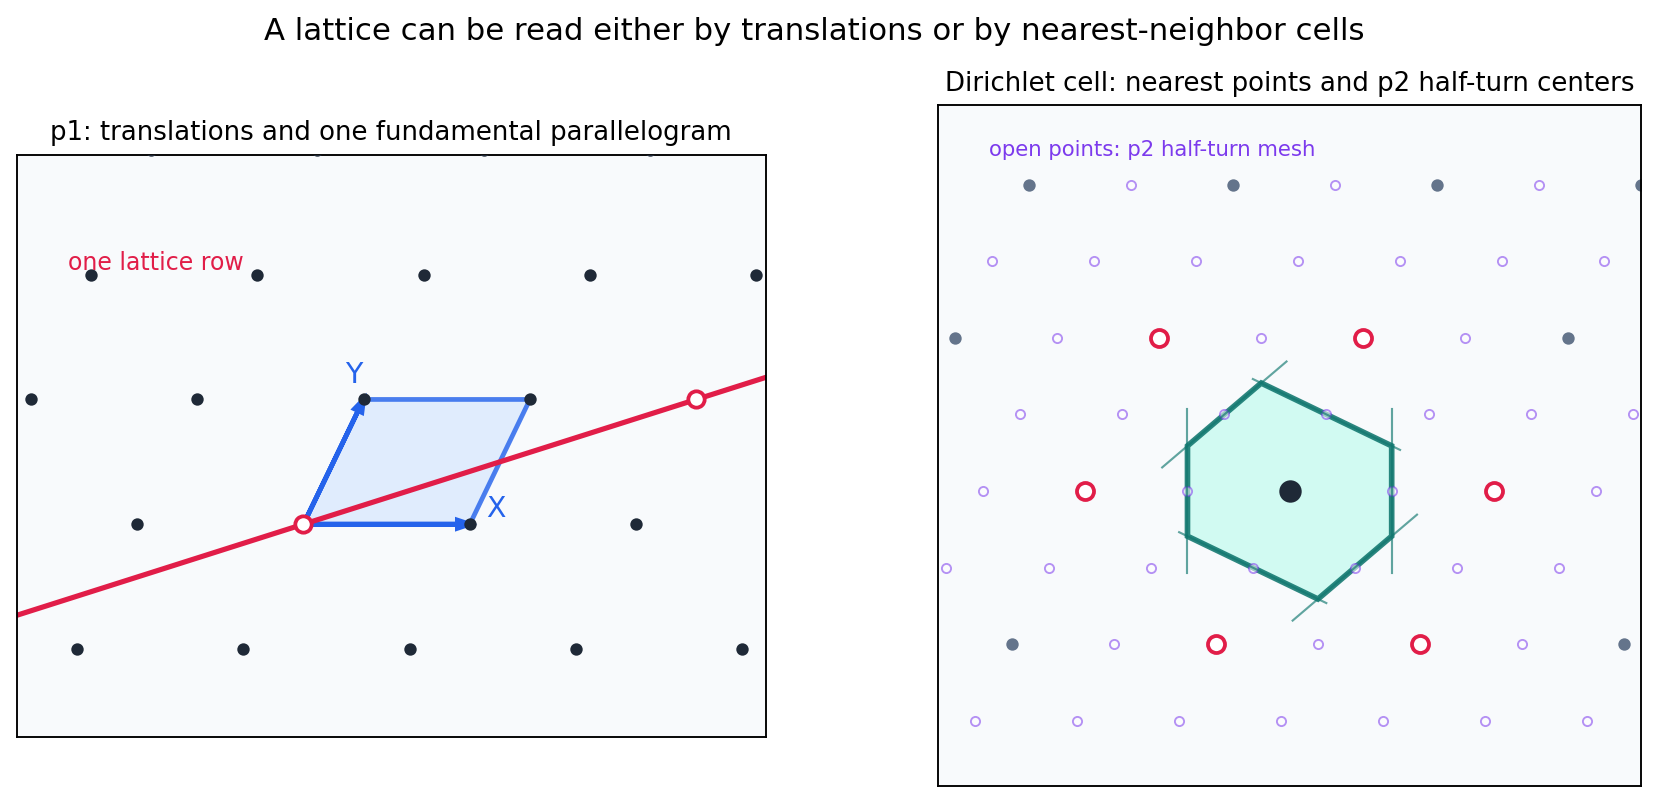

{'basis_X': [1.8, 0.0],
 'basis_Y': [0.65, 1.35],
 'fundamental_area': 2.43,
 'dirichlet_area': 2.43,
 'area_error': 0.0,
 'dirichlet_side_count': 6,
 'dirichlet_neighbor_count': 6,
 'central_symmetry_residual': 3.510833468576701e-16,
 'basis_change_matrix': [[1, 1], [0, 1]],
 'basis_change_det': 1,
 'changed_basis_area': 2.43,
 'half_turn_translation_residual': 0.0,
 'lattice_row_determinant': '0'}

In [2]:
X = np.array([1.80, 0.00])
Y = np.array([0.65, 1.35])
coords, lattice_points, origin_index, dirichlet_poly, neighbor_indices = dirichlet_cell_for_basis(X, Y, span=4)
neighbor_points = lattice_points[neighbor_indices]
fundamental_poly = np.array([[0, 0], X, X + Y, Y])
fundamental_area = abs(float(np.linalg.det(np.column_stack([X, Y]))))
dirichlet_area = abs(shoelace_area(dirichlet_poly))
area_error = abs(dirichlet_area - fundamental_area)

U = np.array([[1, 1], [0, 1]], dtype=int)
changed_basis = np.column_stack([X, Y]) @ U
basis_change_det = int(round(np.linalg.det(U)))
changed_area = abs(float(np.linalg.det(changed_basis)))

z = np.array([0.31, 0.47])
H = lambda center, point: 2 * center - point
half_turn_translation_residual = float(np.linalg.norm(H(X / 2, H(np.zeros(2), z)) - (z + X)))

n = sp.symbols("n", integer=True)
collinearity_det = sp.Matrix([
    [0, 0, 1],
    [4, 6, 1],
    [sp.Rational(4, 2) * n, sp.Rational(6, 2) * n, 1],
]).det()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
for ax in axes:
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("#f8fafc")

ax = axes[0]
ax.scatter(lattice_points[:, 0], lattice_points[:, 1], s=18, color=PALETTE["ink"], zorder=3)
ax.add_patch(Polygon(fundamental_poly, closed=True, facecolor="#dbeafe", edgecolor=PALETTE["blue"], linewidth=2, alpha=0.82))
ax.annotate("X", xy=X, xytext=X + np.array([0.18, 0.08]), color=PALETTE["blue"], fontsize=12)
ax.annotate("Y", xy=Y, xytext=Y + np.array([-0.2, 0.18]), color=PALETTE["blue"], fontsize=12)
ax.arrow(0, 0, X[0], X[1], head_width=0.09, length_includes_head=True, color=PALETTE["blue"], linewidth=2)
ax.arrow(0, 0, Y[0], Y[1], head_width=0.09, length_includes_head=True, color=PALETTE["blue"], linewidth=2)
row_direction = 2 * X + Y
row_points = np.array([k * row_direction for k in range(-2, 3)])
ax.plot(row_points[:, 0], row_points[:, 1], color=PALETTE["coral"], linewidth=2.2)
ax.scatter(row_points[:, 0], row_points[:, 1], s=48, facecolor="white", edgecolor=PALETTE["coral"], linewidth=1.6, zorder=4)
ax.text(-2.55, 2.75, "one lattice row", color=PALETTE["coral"], fontsize=10)
ax.set_title("p1: translations and one fundamental parallelogram", fontsize=11)
ax.set_xlim(-3.1, 5.0)
ax.set_ylim(-2.3, 4.0)

ax = axes[1]
ax.scatter(lattice_points[:, 0], lattice_points[:, 1], s=18, color="#64748b", zorder=2)
ax.scatter(neighbor_points[:, 0], neighbor_points[:, 1], s=52, facecolor="white", edgecolor=PALETTE["coral"], linewidth=1.6, zorder=4)
ax.scatter([0], [0], s=72, color=PALETTE["ink"], zorder=5)
ax.add_patch(Polygon(dirichlet_poly, closed=True, facecolor="#ccfbf1", edgecolor=PALETTE["teal"], linewidth=2.4, alpha=0.88))
for pnt in neighbor_points:
    midpoint = 0.5 * pnt
    direction = np.array([-pnt[1], pnt[0]])
    direction = direction / np.linalg.norm(direction)
    segment = np.array([midpoint - 0.72 * direction, midpoint + 0.72 * direction])
    ax.plot(segment[:, 0], segment[:, 1], color="#0f766e", linewidth=0.9, alpha=0.65)
half_centers = np.array([0.5 * (i * X + j * Y) for i in range(-4, 5) for j in range(-4, 5)])
ax.scatter(half_centers[:, 0], half_centers[:, 1], s=15, facecolor="white", edgecolor=PALETTE["violet"], linewidth=0.8, alpha=0.55, zorder=1)
ax.text(-2.65, 2.95, "open points: p2 half-turn mesh", color=PALETTE["violet"], fontsize=9)
ax.set_title("Dirichlet cell: nearest points and p2 half-turn centers", fontsize=11)
ax.set_xlim(-3.1, 3.1)
ax.set_ylim(-2.6, 3.4)
fig.suptitle("A lattice can be read either by translations or by nearest-neighbor cells", fontsize=13)

lattice_path = save_figure(fig, DIRS["figures"] / "lattice-dirichlet-cell.png")
visual_artifacts.append(lattice_path)

lattice_payload = {
    "basis_X": X.round(6).tolist(),
    "basis_Y": Y.round(6).tolist(),
    "fundamental_area": fundamental_area,
    "dirichlet_area": dirichlet_area,
    "area_error": area_error,
    "dirichlet_side_count": int(len(dirichlet_poly)),
    "dirichlet_neighbor_count": int(len(neighbor_indices)),
    "central_symmetry_residual": central_symmetry_residual(dirichlet_poly),
    "basis_change_matrix": U.tolist(),
    "basis_change_det": basis_change_det,
    "changed_basis_area": changed_area,
    "half_turn_translation_residual": half_turn_translation_residual,
    "lattice_row_determinant": str(sp.simplify(collinearity_det)),
}
assert area_error < 1e-10
assert lattice_payload["dirichlet_side_count"] == 6
assert lattice_payload["dirichlet_neighbor_count"] == 6
assert lattice_payload["central_symmetry_residual"] < 1e-9
assert basis_change_det == 1 and abs(changed_area - fundamental_area) < 1e-12
assert half_turn_translation_residual < 1e-12
assert sp.simplify(collinearity_det) == 0

lattice_check_path = write_json_artifact(DIRS["checks"] / "lattice-dirichlet-invariants.json", lattice_payload)
lattice_data_path = write_json_artifact(DIRS["data"] / "lattice-neighbors.json", {
    "neighbor_lattice_coordinates": coords[neighbor_indices].tolist(),
    "neighbor_points": neighbor_points.round(6).tolist(),
    "dirichlet_vertices": dirichlet_poly.round(6).tolist(),
})
check_artifacts.append(lattice_check_path)
data_artifacts.append(lattice_data_path)

display_named_artifact(lattice_path, "Lattice basis, Dirichlet cell, and half-turn mesh")
lattice_payload


## 2. Motifs: From Translation Tiles to Glide Patterns

A wallpaper pattern is not just a point lattice; it is a motif attached to the lattice. The motif below is deliberately synthetic and asymmetric. In the left panel it is repeated by translations only, so the symmetry is the same as `p1` unless the motif itself accidentally has symmetry.

The right panel adds a glide reflection: reflect the motif across a horizontal axis and shift it by half a tile. The important group relation is computationally visible: doing the same glide twice is not the identity; it is a full translation along the glide direction. This is the same type of distinction the source pages use when comparing a plain translated design with a design whose colors or orientations are interchanged by glides.


### Synthetic motif: translation versus glide repetition

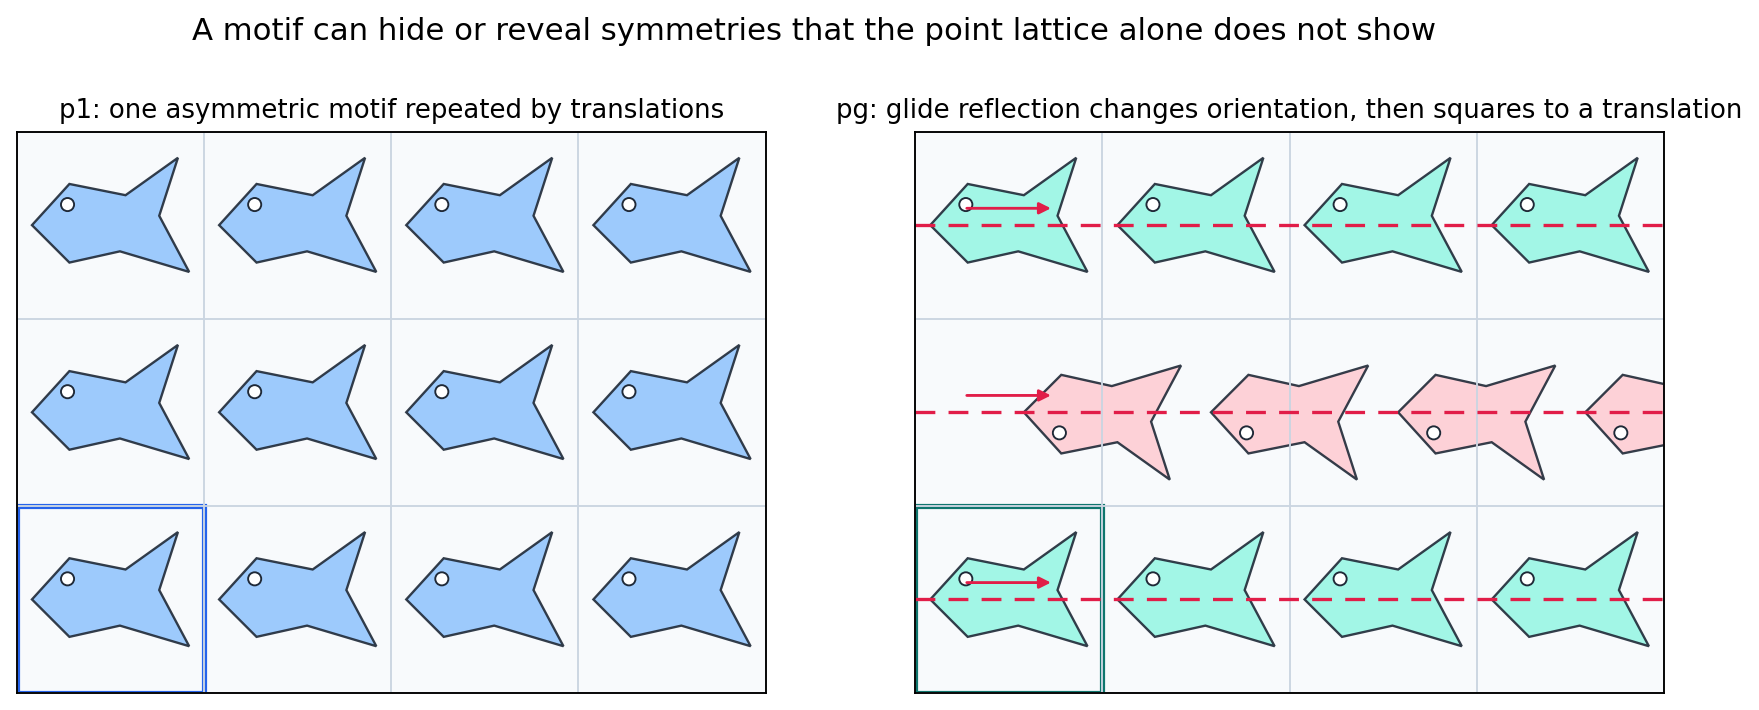

{'glide_twice_translation_residual': 0.0, 'motif_vertices': 8}

In [3]:
motif = np.array([
    [0.08, 0.50], [0.28, 0.72], [0.58, 0.66], [0.86, 0.86],
    [0.76, 0.55], [0.92, 0.25], [0.55, 0.36], [0.28, 0.30],
])


def draw_motif(ax, offset=(0, 0), flip_y=False, color="#38bdf8", edge="#1f2937", alpha=0.9):
    pts = motif.copy()
    if flip_y:
        pts[:, 1] = 1 - pts[:, 1]
        pts[:, 0] += 0.50
    pts[:, 0] += offset[0]
    pts[:, 1] += offset[1]
    ax.add_patch(Polygon(pts, closed=True, facecolor=color, edgecolor=edge, linewidth=1.0, alpha=alpha))
    eye = np.array([0.27, 0.61])
    if flip_y:
        eye[1] = 1 - eye[1]
        eye[0] += 0.50
    eye += np.array(offset)
    ax.add_patch(Circle(eye, 0.035, facecolor="white", edgecolor=edge, linewidth=0.8))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 3)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("#f8fafc")
    for x in range(5):
        ax.plot([x, x], [0, 3], color=PALETTE["grid"], linewidth=0.8)
    for y in range(4):
        ax.plot([0, 4], [y, y], color=PALETTE["grid"], linewidth=0.8)

for i in range(4):
    for j in range(3):
        draw_motif(axes[0], (i, j), flip_y=False, color="#93c5fd")
axes[0].add_patch(Rectangle((0, 0), 1, 1, facecolor="none", edgecolor=PALETTE["blue"], linewidth=2.2))
axes[0].set_title("p1: one asymmetric motif repeated by translations", fontsize=11)

for i in range(4):
    for j in range(3):
        flip = (j % 2 == 1)
        draw_motif(axes[1], (i, j), flip_y=flip, color="#99f6e4" if not flip else "#fecdd3")
for y in [0.5, 1.5, 2.5]:
    axes[1].plot([0, 4], [y, y], color=PALETTE["coral"], linestyle=(0, (6, 4)), linewidth=1.4)
    axes[1].add_patch(FancyArrowPatch((0.25, y + 0.09), (0.75, y + 0.09), arrowstyle="-|>", mutation_scale=10, color=PALETTE["coral"], linewidth=1.2))
axes[1].add_patch(Rectangle((0, 0), 1, 1, facecolor="none", edgecolor=PALETTE["teal"], linewidth=2.2))
axes[1].set_title("pg: glide reflection changes orientation, then squares to a translation", fontsize=11)
fig.suptitle("A motif can hide or reveal symmetries that the point lattice alone does not show", fontsize=13)

motif_path = save_figure(fig, DIRS["figures"] / "wallpaper-motif-tile.png")
visual_artifacts.append(motif_path)

sample = motif - np.array([0.0, 0.5])
glide = lambda pts: np.column_stack([pts[:, 0] + 0.5, -pts[:, 1]])
glide_twice = glide(glide(sample))
glide_residual = float(np.max(np.linalg.norm(glide_twice - (sample + np.array([1.0, 0.0])), axis=1)))
assert glide_residual < 1e-12

display_named_artifact(motif_path, "Synthetic motif: translation versus glide repetition")
{"glide_twice_translation_residual": glide_residual, "motif_vertices": len(motif)}


## 3. Six Patterns of Bricks

The source chapter uses familiar rectangle or domino patterns to make wallpaper groups less abstract. A single brick has its own local symmetries, but a brick pattern may preserve all, some, or none of them globally. The six schematics here are not copied from the book; they are compact diagnostic diagrams. Dashed lines mark mirrors, small circles mark half-turns, small squares mark quarter-turns, and half-arrows mark glides.

The point of the comparison is not artistic realism. It is to see how the same `2:1` rectangle supports different global groups depending on alignment, offset, and orientation.


### Six brick-pattern symmetry schematics

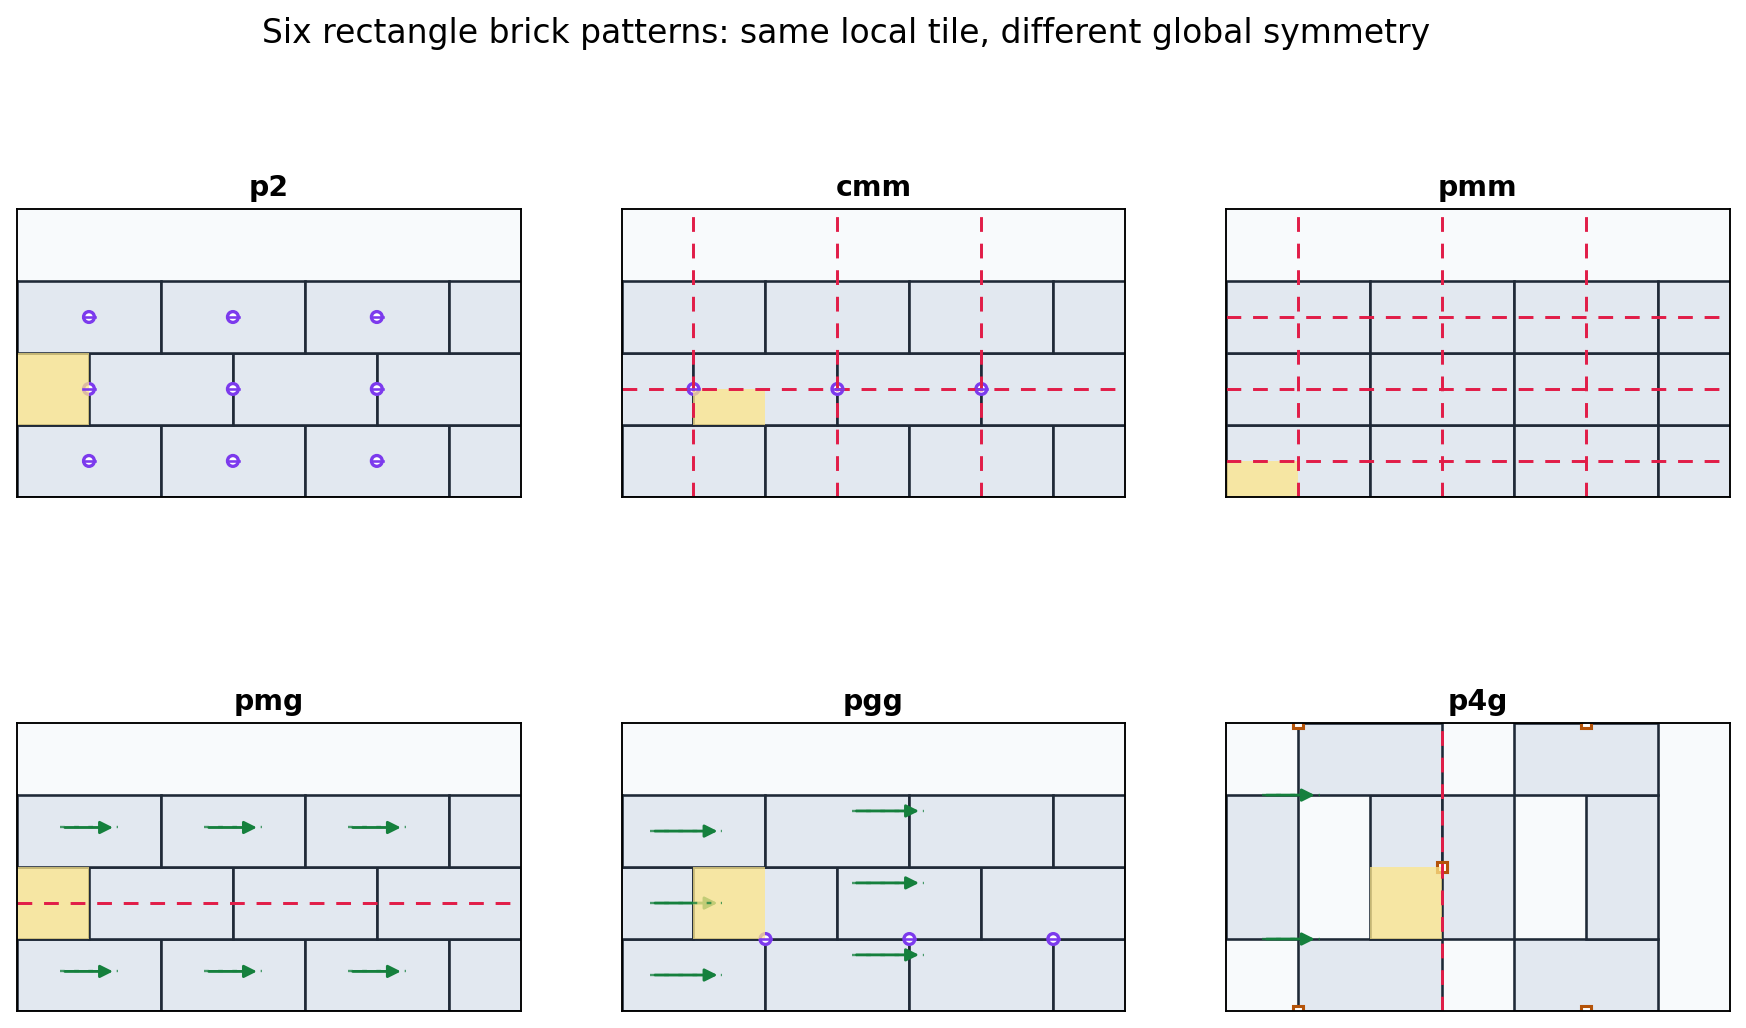

Brick comparison table: `artifacts/chapter-04/tables/brick-patterns.csv`

{'groups': ['p2', 'cmm', 'pmm', 'pmg', 'pgg', 'p4g'],
 'group_count': 6,
 'all_brick_ratios': [2.0],
 'glide_twice_translation_residual': 0.0}

In [4]:
def add_brick(ax, x, y, w=2.0, h=1.0, angle=0.0, fill="#e2e8f0", edge=PALETTE["ink"]):
    ax.add_patch(Rectangle((x, y), w, h, angle=angle, facecolor=fill, edgecolor=edge, linewidth=1.1))


def add_half_turn(ax, x, y, color=PALETTE["violet"]):
    ax.add_patch(Circle((x, y), 0.075, facecolor="white", edgecolor=color, linewidth=1.4))
    ax.plot([x - 0.08, x + 0.08], [y, y], color=color, linewidth=1.1)


def add_quarter_turn(ax, x, y, color=PALETTE["gold"]):
    ax.add_patch(Rectangle((x - 0.07, y - 0.07), 0.14, 0.14, facecolor="white", edgecolor=color, linewidth=1.3))


def add_mirror(ax, x0, y0, x1, y1, color=PALETTE["coral"]):
    ax.plot([x0, x1], [y0, y1], color=color, linestyle=(0, (5, 4)), linewidth=1.25)


def add_glide(ax, x0, y0, x1, y1, color=PALETTE["green"]):
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle="-|>", mutation_scale=11, color=color, linewidth=1.2))
    ax.plot([x0, x1], [y0, y1], color=color, linestyle=(0, (2, 4)), linewidth=1.0, alpha=0.75)


def running_bond(ax, rows=3, cols=4, offset_rows=True):
    for j in range(rows):
        offset = 1.0 if (offset_rows and j % 2) else 0.0
        for i in range(-1, cols):
            add_brick(ax, 2 * i + offset, j)


def aligned_grid(ax, rows=3, cols=4):
    for j in range(rows):
        for i in range(cols):
            add_brick(ax, 2 * i, j)


def p4g_patch(ax):
    blocks = [
        (1.0, 0.0, 2.0, 1.0), (2.0, 1.0, 1.0, 2.0),
        (1.0, 3.0, 2.0, 1.0), (0.0, 1.0, 1.0, 2.0),
        (4.0, 0.0, 2.0, 1.0), (5.0, 1.0, 1.0, 2.0),
        (4.0, 3.0, 2.0, 1.0), (3.0, 1.0, 1.0, 2.0),
    ]
    for x, y, w, h in blocks:
        add_brick(ax, x, y, w=w, h=h)

brick_records = [
    {"group": "p2", "visible_generators": "translations and half-turns", "local_brick_symmetry_kept": "C2", "fundamental_region": "half brick", "brick_ratio": 2.0},
    {"group": "cmm", "visible_generators": "centered mirrors and half-turns", "local_brick_symmetry_kept": "D1 plus centers", "fundamental_region": "quarter brick", "brick_ratio": 2.0},
    {"group": "pmm", "visible_generators": "perpendicular mirrors", "local_brick_symmetry_kept": "D2", "fundamental_region": "quarter brick", "brick_ratio": 2.0},
    {"group": "pmg", "visible_generators": "mirrors plus glides", "local_brick_symmetry_kept": "D1", "fundamental_region": "half brick", "brick_ratio": 2.0},
    {"group": "pgg", "visible_generators": "two glide directions", "local_brick_symmetry_kept": "C2", "fundamental_region": "half brick", "brick_ratio": 2.0},
    {"group": "p4g", "visible_generators": "quarter-turns and glides", "local_brick_symmetry_kept": "D1 in a square block", "fundamental_region": "half brick", "brick_ratio": 2.0},
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7.2))
axes = axes.ravel()
for ax, record in zip(axes, brick_records):
    ax.set_aspect("equal")
    ax.set_xlim(0, 7)
    ax.set_ylim(0, 4)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("#f8fafc")
    ax.set_title(record["group"], fontsize=12, fontweight="bold")

running_bond(axes[0])
for x in [1, 3, 5]:
    for y in [0.5, 1.5, 2.5]:
        add_half_turn(axes[0], x, y)
axes[0].add_patch(Rectangle((0, 1), 1, 1, facecolor="#fde68a", edgecolor="none", alpha=0.75))

running_bond(axes[1])
for x in [1, 3, 5]:
    add_mirror(axes[1], x, 0, x, 4)
add_mirror(axes[1], 0, 1.5, 7, 1.5)
for x in [1, 3, 5]:
    add_half_turn(axes[1], x, 1.5)
axes[1].add_patch(Rectangle((1, 1), 1, 0.5, facecolor="#fde68a", edgecolor="none", alpha=0.75))

aligned_grid(axes[2])
for x in [1, 3, 5]:
    add_mirror(axes[2], x, 0, x, 4)
for y in [0.5, 1.5, 2.5]:
    add_mirror(axes[2], 0, y, 7, y)
axes[2].add_patch(Rectangle((0, 0), 1, 0.5, facecolor="#fde68a", edgecolor="none", alpha=0.75))

running_bond(axes[3])
add_mirror(axes[3], 0, 1.5, 7, 1.5)
for x in [0.6, 2.6, 4.6]:
    add_glide(axes[3], x, 0.55, x + 0.8, 0.55)
    add_glide(axes[3], x, 2.55, x + 0.8, 2.55)
axes[3].add_patch(Rectangle((0, 1), 1, 1, facecolor="#fde68a", edgecolor="none", alpha=0.75))

running_bond(axes[4])
for y in [0.5, 1.5, 2.5]:
    add_glide(axes[4], 0.4, y, 1.4, y)
    add_glide(axes[4], 3.2, y + 0.28, 4.2, y + 0.28)
for x in [2, 4, 6]:
    add_half_turn(axes[4], x, 1.0)
axes[4].add_patch(Rectangle((1, 1), 1, 1, facecolor="#fde68a", edgecolor="none", alpha=0.75))

p4g_patch(axes[5])
for x, y in [(3, 2), (1, 0), (5, 0), (1, 4), (5, 4)]:
    add_quarter_turn(axes[5], x, y)
add_mirror(axes[5], 3, 0, 3, 4)
for y in [1, 3]:
    add_glide(axes[5], 0.5, y, 1.3, y)
axes[5].add_patch(Rectangle((2.0, 1.0), 1.0, 1.0, facecolor="#fde68a", edgecolor="none", alpha=0.75))

fig.suptitle("Six rectangle brick patterns: same local tile, different global symmetry", fontsize=14)
brick_path = save_figure(fig, DIRS["figures"] / "brick-pattern-comparison.png")
visual_artifacts.append(brick_path)
brick_table_path = write_csv(DIRS["tables"] / "brick-patterns.csv", brick_records)
table_artifacts.append(brick_table_path)

brick_payload = {
    "groups": [row["group"] for row in brick_records],
    "group_count": len(brick_records),
    "all_brick_ratios": sorted(set(row["brick_ratio"] for row in brick_records)),
    "glide_twice_translation_residual": glide_residual,
}
assert brick_payload["group_count"] == 6
assert set(brick_payload["groups"]) == {"p2", "cmm", "pmm", "pmg", "pgg", "p4g"}
assert brick_payload["all_brick_ratios"] == [2.0]
brick_check_path = write_json_artifact(DIRS["checks"] / "wallpaper-brick-invariants.json", brick_payload)
check_artifacts.append(brick_check_path)

display_named_artifact(brick_path, "Six brick-pattern symmetry schematics", width=860)
display(Markdown(f"Brick comparison table: `{rel(brick_table_path)}`"))
brick_payload


## 4. The Crystallographic Restriction

A discrete planar lattice cannot have arbitrary rotation periods. The geometric reason is a nearest-center contradiction. Put two rotation centers `P` and `Q` at the least positive distance among centers of the same period. Rotate `P` about `Q`, then rotate `Q` about the new point. For periods `5` and greater than `6`, this construction produces a same-period center closer than `P` and `Q`, contradicting the choice of a minimum. Period `6` is the borderline case where one new center falls back on `P`.

There is also an algebraic version. A rotation that preserves a lattice acts by an integer matrix in a lattice basis. If it has finite order and determinant `1`, its trace must be `2*cos(2*pi/n)`, an integer. That integer trace condition leaves exactly the periods `2, 3, 4, 6`.


In [5]:
P = np.array([0.0, 0.0])
Q = np.array([1.0, 0.0])


def rot(theta: float) -> np.ndarray:
    return np.array([[cos(theta), -sin(theta)], [sin(theta), cos(theta)]])


def barlow_points(order: int):
    theta = 2 * pi / order
    P_prime = Q + rot(theta) @ (P - Q)
    Q_prime = P_prime + rot(theta) @ (Q - P_prime)
    return P_prime, Q_prime

rotation_rows = []
for order in range(2, 13):
    trace_exact = sp.simplify(2 * sp.cos(2 * sp.pi / order))
    trace_is_integer = trace_exact.is_Integer
    row = {
        "order": order,
        "trace_2cos": str(trace_exact),
        "trace_is_integer": bool(trace_is_integer),
        "lattice_allowed_by_trace": bool(order in {2, 3, 4, 6}),
    }
    if order >= 3:
        P_prime, Q_prime = barlow_points(order)
        candidates = {
            "PP_prime": float(np.linalg.norm(P_prime - P)),
            "PQ_prime": float(np.linalg.norm(Q_prime - P)),
            "Q_primeQ": float(np.linalg.norm(Q_prime - Q)),
        }
        row.update({
            "shortest_new_center_ratio": min(candidates.values()),
            "candidate_distances": candidates,
        })
    else:
        row.update({"shortest_new_center_ratio": 1.0, "candidate_distances": {}})
    rotation_rows.append(row)

allowed_by_trace = {row["order"] for row in rotation_rows if row["trace_is_integer"]}
assert allowed_by_trace == {2, 3, 4, 6}
for row in rotation_rows:
    order = row["order"]
    if order == 5 or order > 6:
        assert row["shortest_new_center_ratio"] < 1.0

orders_for_geometry = list(range(3, 9))
fig = make_subplots(rows=1, cols=2, subplot_titles=("Shortest new-center distance / PQ", "Barlow construction"), horizontal_spacing=0.12)
fig.add_trace(go.Scatter(
    x=[row["order"] for row in rotation_rows],
    y=[row["shortest_new_center_ratio"] for row in rotation_rows],
    mode="lines+markers",
    marker=dict(size=9, color=["#15803d" if row["order"] in {2, 3, 4, 6} else "#e11d48" for row in rotation_rows]),
    text=[f"n={row['order']} trace={row['trace_2cos']}" for row in rotation_rows],
    hovertemplate="%{text}<br>ratio=%{y:.3f}<extra></extra>",
    name="distance ratio",
), row=1, col=1)
fig.add_hline(y=1, line_dash="dash", line_color="#64748b", row=1, col=1)

geometry_trace_start = 1
for order in orders_for_geometry:
    P_prime, Q_prime = barlow_points(order)
    pts = np.vstack([P, Q, P_prime, Q_prime, P])
    visible = order == 5
    fig.add_trace(go.Scatter(
        x=pts[:, 0], y=pts[:, 1],
        mode="lines+markers+text",
        text=["P", "Q", "P'", "Q'", ""],
        textposition="top center",
        marker=dict(size=9, color="#2563eb"),
        line=dict(color="#1f2937", width=2),
        visible=visible,
        name=f"n={order}",
        hovertemplate=f"order {order}<br>x=%{{x:.3f}} y=%{{y:.3f}}<extra></extra>",
    ), row=1, col=2)

buttons = []
for idx, order in enumerate(orders_for_geometry):
    visible = [True] + [False] * len(orders_for_geometry)
    visible[geometry_trace_start + idx] = True
    buttons.append(dict(label=f"n={order}", method="update", args=[{"visible": visible}, {"title": f"Crystallographic restriction experiment, n={order}"}]))
fig.update_layout(
    title="Crystallographic restriction experiment",
    width=980,
    height=520,
    updatemenus=[dict(type="buttons", buttons=buttons, x=0.62, y=1.16, direction="right")],
    showlegend=False,
)
fig.update_xaxes(title_text="rotation order n", row=1, col=1)
fig.update_yaxes(title_text="ratio", range=[-0.05, 2.1], row=1, col=1)
fig.update_xaxes(scaleanchor="y2", scaleratio=1, range=[-0.35, 1.75], row=1, col=2)
fig.update_yaxes(range=[-1.95, 1.05], row=1, col=2)

rotation_html_path = DIRS["html"] / "rotation-order-restriction.html"
fig.write_html(rotation_html_path, include_plotlyjs="cdn", full_html=True)
html_artifacts.append(rotation_html_path)

rotation_check_path = write_json_artifact(DIRS["checks"] / "rotation-order-restriction.json", {
    "allowed_orders_by_integer_trace": sorted(allowed_by_trace),
    "rows": rotation_rows,
    "barlow_contradiction_orders_checked": [row["order"] for row in rotation_rows if row["order"] == 5 or row["order"] > 6],
})
check_artifacts.append(rotation_check_path)

display_named_artifact(rotation_html_path, "Interactive rotation-order restriction", width=900)
{"allowed_orders_by_integer_trace": sorted(allowed_by_trace), "html": rel(rotation_html_path)}


### Interactive rotation-order restriction

{'allowed_orders_by_integer_trace': [2, 3, 4, 6],
 'html': 'artifacts/chapter-04/html/rotation-order-restriction.html'}

## 5. Regular Tessellations, Duals, and Cell Adjacency

A regular tessellation `{p,q}` has regular `p`-gons for faces and exactly `q` faces meeting at each vertex. The angle equation is the whole classification in one line:

`q * (1 - 2/p) * pi = 2*pi`, equivalently `(p - 2)(q - 2) = 4`.

Only three positive integer solutions with `p,q >= 3` occur in the Euclidean plane: hexagons `{6,3}`, squares `{4,4}`, and triangles `{3,6}`. The dual operation swaps faces and vertices, so `{6,3}` and `{3,6}` are dual while `{4,4}` is self-dual. The middle panel overlays a finite cell-adjacency graph to make the dual idea computational: cells become graph vertices, and shared sides become graph edges.


### Regular tessellations and square-cell adjacency

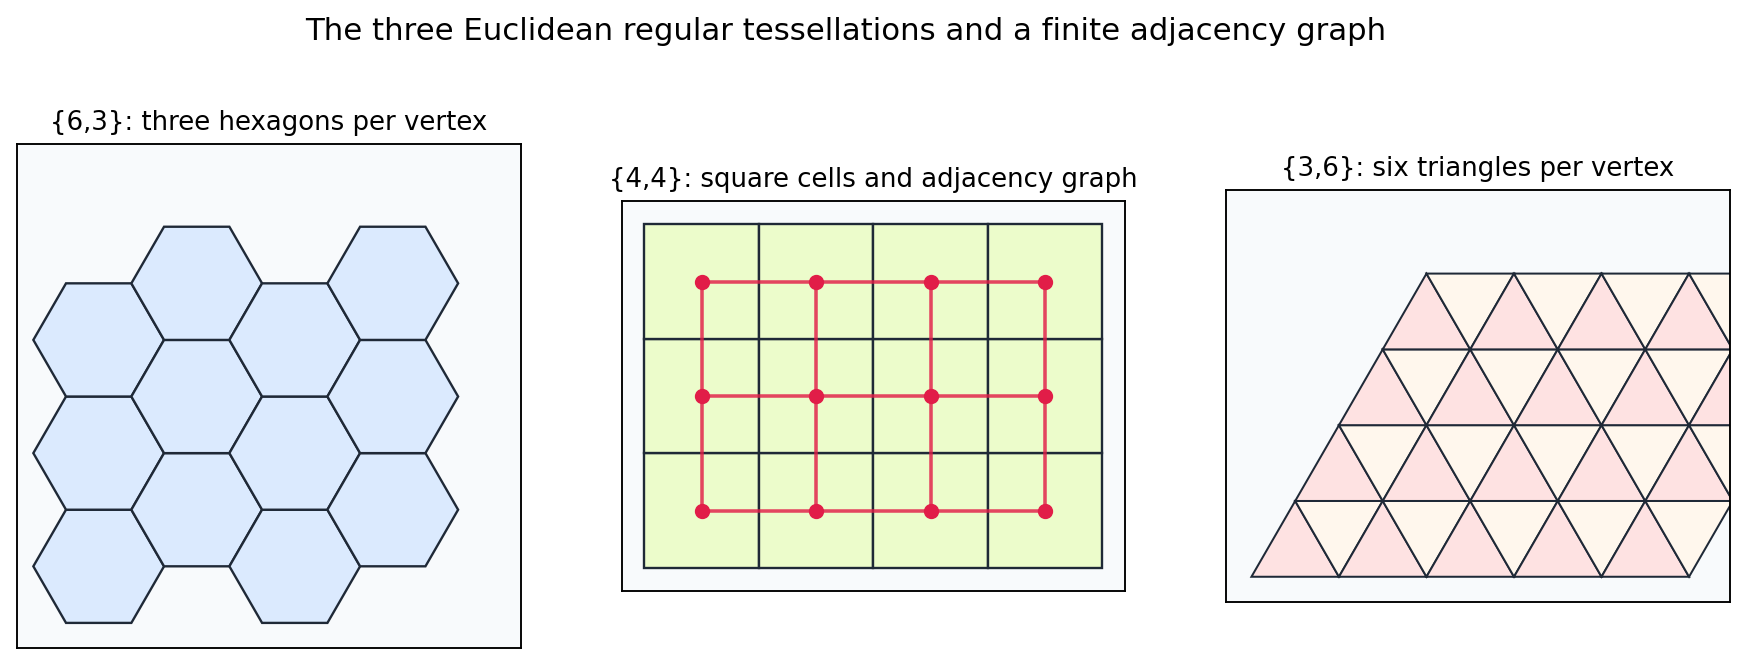

Regular tessellation table: `artifacts/chapter-04/tables/regular-tessellations.csv`

[{'symbol': '{6,3}',
  'p': 6,
  'q': 3,
  'dual': '{3,6}',
  'angle_sum_over_2pi': 1.0000000000000002,
  'factor_check': 4},
 {'symbol': '{4,4}',
  'p': 4,
  'q': 4,
  'dual': '{4,4}',
  'angle_sum_over_2pi': 1.0,
  'factor_check': 4},
 {'symbol': '{3,6}',
  'p': 3,
  'q': 6,
  'dual': '{6,3}',
  'angle_sum_over_2pi': 1.0000000000000002,
  'factor_check': 4}]

In [6]:
def regular_polygon_vertices(center, sides, radius=0.45, angle0=0.0):
    theta = angle0 + np.linspace(0, 2 * pi, sides, endpoint=False)
    return np.column_stack([center[0] + radius * np.cos(theta), center[1] + radius * np.sin(theta)])

fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax in axes:
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("#f8fafc")

R = 0.48
for i in range(4):
    for j in range(3):
        center = np.array([1.5 * R * i, sqrt(3) * R * (j + 0.5 * (i % 2))])
        poly = regular_polygon_vertices(center, 6, R, angle0=0)
        axes[0].add_patch(Polygon(poly, closed=True, facecolor="#dbeafe", edgecolor=PALETTE["ink"], linewidth=1.0))
axes[0].set_title("{6,3}: three hexagons per vertex", fontsize=11)
axes[0].set_xlim(-0.6, 3.1)
axes[0].set_ylim(-0.6, 3.1)

for i in range(4):
    for j in range(3):
        axes[1].add_patch(Rectangle((i, j), 1, 1, facecolor="#ecfccb", edgecolor=PALETTE["ink"], linewidth=1.0))
G = nx.grid_2d_graph(4, 3)
for a_node, b_node in G.edges():
    a_pt = np.array([a_node[0] + 0.5, a_node[1] + 0.5])
    b_pt = np.array([b_node[0] + 0.5, b_node[1] + 0.5])
    axes[1].plot([a_pt[0], b_pt[0]], [a_pt[1], b_pt[1]], color=PALETTE["coral"], linewidth=1.5, alpha=0.82)
for node in G.nodes():
    axes[1].scatter([node[0] + 0.5], [node[1] + 0.5], s=30, color=PALETTE["coral"], zorder=3)
axes[1].set_title("{4,4}: square cells and adjacency graph", fontsize=11)
axes[1].set_xlim(-0.2, 4.2)
axes[1].set_ylim(-0.2, 3.2)

a = np.array([0.86, 0.0])
b = np.array([0.43, sqrt(3) * 0.43])
for i in range(5):
    for j in range(4):
        p0 = i * a + j * b
        tri1 = np.array([p0, p0 + a, p0 + b])
        tri2 = np.array([p0 + a + b, p0 + b, p0 + a])
        axes[2].add_patch(Polygon(tri1, closed=True, facecolor="#fee2e2", edgecolor=PALETTE["ink"], linewidth=0.85))
        axes[2].add_patch(Polygon(tri2, closed=True, facecolor="#fff7ed", edgecolor=PALETTE["ink"], linewidth=0.85))
axes[2].set_title("{3,6}: six triangles per vertex", fontsize=11)
axes[2].set_xlim(-0.25, 4.7)
axes[2].set_ylim(-0.25, 3.8)

fig.suptitle("The three Euclidean regular tessellations and a finite adjacency graph", fontsize=13)
tess_path = save_figure(fig, DIRS["figures"] / "tessellation-adjacency.png")
visual_artifacts.append(tess_path)

regular_rows = []
for p_val, q_val in [(6, 3), (4, 4), (3, 6)]:
    face_angle = (1 - 2 / p_val) * pi
    regular_rows.append({
        "symbol": f"{{{p_val},{q_val}}}",
        "p": p_val,
        "q": q_val,
        "dual": f"{{{q_val},{p_val}}}",
        "angle_sum_over_2pi": q_val * face_angle / (2 * pi),
        "factor_check": (p_val - 2) * (q_val - 2),
    })
assert all(abs(row["angle_sum_over_2pi"] - 1.0) < 1e-12 for row in regular_rows)
assert all(row["factor_check"] == 4 for row in regular_rows)
assert nx.is_connected(G)

regular_table_path = write_csv(DIRS["tables"] / "regular-tessellations.csv", regular_rows)
tess_graph_path = write_json_artifact(DIRS["data"] / "tessellation-graph.json", {
    "graph": "4 by 3 square cell adjacency graph",
    "node_count": G.number_of_nodes(),
    "edge_count": G.number_of_edges(),
    "degree_sequence": sorted(dict(G.degree()).values()),
    "connected": nx.is_connected(G),
})
tess_check_path = write_json_artifact(DIRS["checks"] / "tessellation-invariants.json", {
    "regular_tessellations": regular_rows,
    "euclidean_solutions": [row["symbol"] for row in regular_rows],
    "square_adjacency_connected": nx.is_connected(G),
})
table_artifacts.append(regular_table_path)
data_artifacts.append(tess_graph_path)
check_artifacts.append(tess_check_path)

display_named_artifact(tess_path, "Regular tessellations and square-cell adjacency", width=880)
display(Markdown(f"Regular tessellation table: `{rel(regular_table_path)}`"))
regular_rows


## 6. Collinear-Point Problems and Ordinary Lines

A lattice fragment can have many rows of three or more collinear points. Sylvester's problem asks whether a finite noncollinear set can avoid an ordinary line, meaning a line containing exactly two of the points. Kelly's proof says no.

The computational version uses the determinant test for collinearity. For three points `(x_i,y_i)`, the determinant of the matrix with rows `(x_i,y_i,1)` is zero exactly when the points are collinear. Enumerating all pair-lines in a finite set lets us count which lines are ordinary and which contain larger rows. The right panel also marks the proof scaffold: choose a point and a joining line with minimum positive perpendicular distance. If that line had a third point on it, one can form a smaller such distance, contradicting minimality.


### Finite collinear rows and ordinary-line search

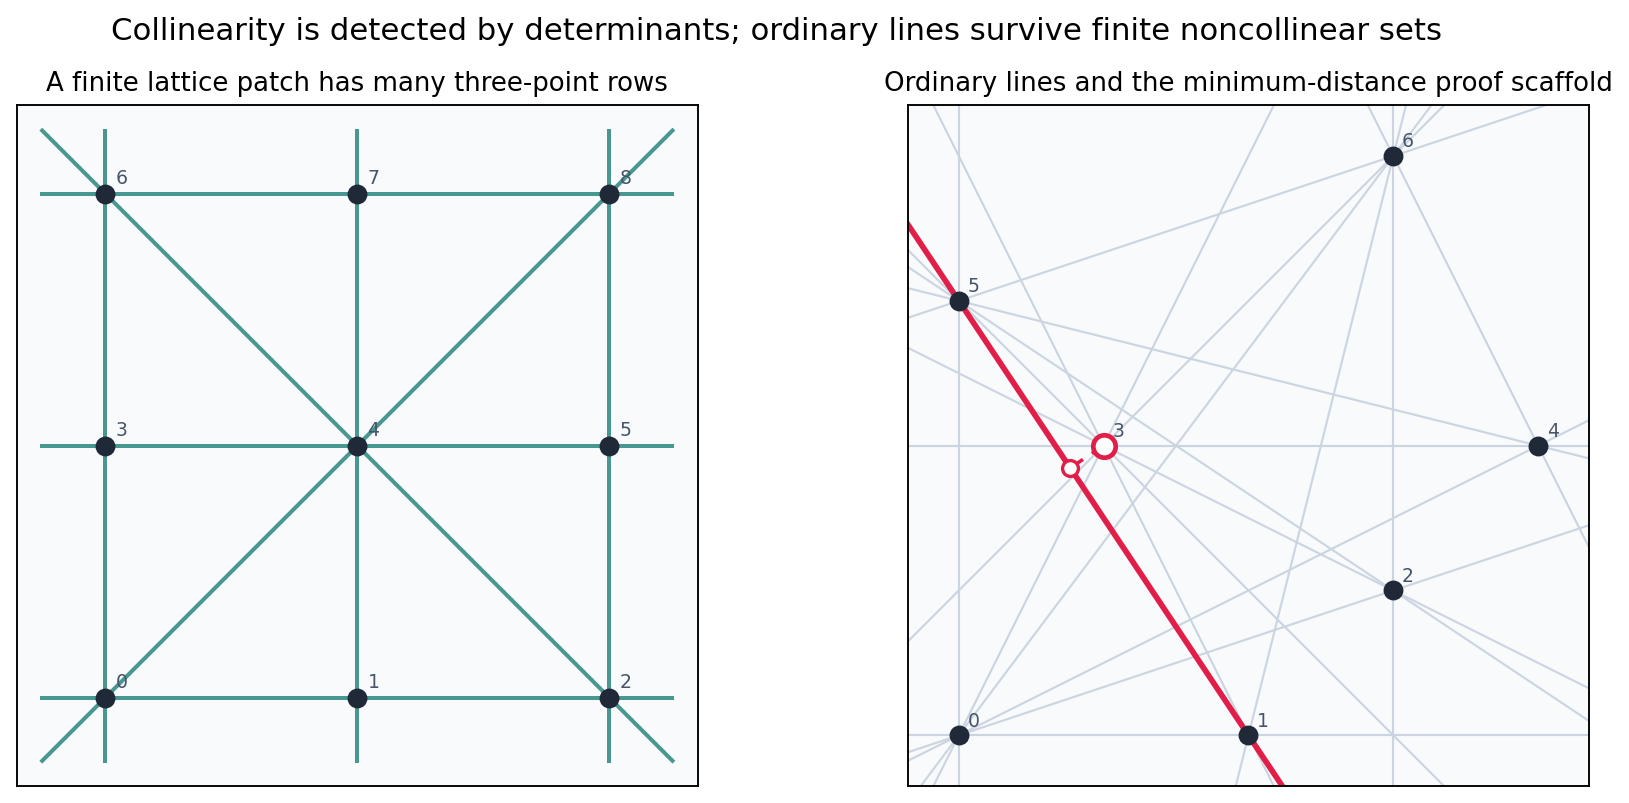

{'grid_points': [(0, 0),
  (1, 0),
  (2, 0),
  (0, 1),
  (1, 1),
  (2, 1),
  (0, 2),
  (1, 2),
  (2, 2)],
 'grid_line_count': 20,
 'grid_triple_line_count': 8,
 'generic_points': [(0, 0), (2, 0), (3, 1), (1, 2), (4, 2), (0, 3), (3, 4)],
 'generic_line_count': 19,
 'generic_ordinary_line_count': 18,
 'kelly_minimum_distance_line': (3, 2, -6),
 'kelly_minimum_distance_point_index': 3,
 'kelly_minimum_distance': 0.2773500981126146}

In [7]:
grid_points = [(i, j) for j in range(3) for i in range(3)]
generic_points = [(0, 0), (2, 0), (3, 1), (1, 2), (4, 2), (0, 3), (3, 4)]

grid_lines = enumerate_integer_lines(grid_points)
generic_lines = enumerate_integer_lines(generic_points)
grid_triple_lines = {line: indices for line, indices in grid_lines.items() if len(indices) >= 3}
generic_ordinary_lines = {line: indices for line, indices in generic_lines.items() if len(indices) == 2}


def point_line_distance(point, line):
    A, B, C = line
    x, y = point
    return abs(A * x + B * y + C) / sqrt(A * A + B * B)

best = None
for line, indices in generic_lines.items():
    for idx, point in enumerate(generic_points):
        if idx in indices:
            continue
        d = point_line_distance(point, line)
        if d > 1e-12 and (best is None or d < best[0]):
            best = (d, line, idx, indices)
assert best is not None
best_distance, best_line, best_point_index, best_line_indices = best
assert len(best_line_indices) == 2


def line_segment_for_box(line, xlim, ylim):
    A, B, C = line
    pts = []
    for x in xlim:
        if B != 0:
            y = (-A * x - C) / B
            if ylim[0] - 1e-9 <= y <= ylim[1] + 1e-9:
                pts.append((x, y))
    for y in ylim:
        if A != 0:
            x = (-B * y - C) / A
            if xlim[0] - 1e-9 <= x <= xlim[1] + 1e-9:
                pts.append((x, y))
    unique = []
    for point in pts:
        if not any(np.linalg.norm(np.array(point) - np.array(q)) < 1e-9 for q in unique):
            unique.append(point)
    return unique[:2]


def foot_of_perpendicular(point, line):
    A, B, C = line
    x, y = map(float, point)
    denom = A * A + B * B
    scale = (A * x + B * y + C) / denom
    return np.array([x - A * scale, y - B * scale])

fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.2))
for ax in axes:
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("#f8fafc")

ax = axes[0]
for line, indices in grid_triple_lines.items():
    segment = line_segment_for_box(line, (-0.25, 2.25), (-0.25, 2.25))
    if len(segment) == 2:
        ax.plot([segment[0][0], segment[1][0]], [segment[0][1], segment[1][1]], color=PALETTE["teal"], linewidth=1.7, alpha=0.75)
pts = np.array(grid_points)
ax.scatter(pts[:, 0], pts[:, 1], s=55, color=PALETTE["ink"], zorder=4)
for idx, (x, y) in enumerate(grid_points):
    ax.text(x + 0.04, y + 0.04, str(idx), fontsize=8, color="#475569")
ax.set_xlim(-0.35, 2.35)
ax.set_ylim(-0.35, 2.35)
ax.set_title("A finite lattice patch has many three-point rows", fontsize=11)

ax = axes[1]
xlim = (-0.35, 4.35)
ylim = (-0.35, 4.35)
for line, indices in generic_ordinary_lines.items():
    segment = line_segment_for_box(line, xlim, ylim)
    if len(segment) == 2:
        ax.plot([segment[0][0], segment[1][0]], [segment[0][1], segment[1][1]], color="#cbd5e1", linewidth=0.9)
segment = line_segment_for_box(best_line, xlim, ylim)
if len(segment) == 2:
    ax.plot([segment[0][0], segment[1][0]], [segment[0][1], segment[1][1]], color=PALETTE["coral"], linewidth=2.4)
pts = np.array(generic_points)
ax.scatter(pts[:, 0], pts[:, 1], s=55, color=PALETTE["ink"], zorder=4)
witness = np.array(generic_points[best_point_index])
foot = foot_of_perpendicular(generic_points[best_point_index], best_line)
ax.scatter([witness[0]], [witness[1]], s=90, facecolor="white", edgecolor=PALETTE["coral"], linewidth=2, zorder=5)
ax.plot([witness[0], foot[0]], [witness[1], foot[1]], color=PALETTE["coral"], linestyle=(0, (4, 3)), linewidth=1.5)
ax.scatter([foot[0]], [foot[1]], s=45, facecolor="white", edgecolor=PALETTE["coral"], linewidth=1.4, zorder=5)
for idx, (x, y) in enumerate(generic_points):
    ax.text(x + 0.06, y + 0.06, str(idx), fontsize=8, color="#475569")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_title("Ordinary lines and the minimum-distance proof scaffold", fontsize=11)
fig.suptitle("Collinearity is detected by determinants; ordinary lines survive finite noncollinear sets", fontsize=13)

col_path = save_figure(fig, DIRS["figures"] / "collinearity-ordinary-lines.png")
visual_artifacts.append(col_path)

det_collinear = sp.Matrix([[0, 0, 1], [1, 1, 1], [2, 2, 1]]).det()
det_noncollinear = sp.Matrix([[0, 0, 1], [2, 0, 1], [1, 2, 1]]).det()
assert det_collinear == 0
assert det_noncollinear != 0
assert len(generic_ordinary_lines) > 0

col_data = {
    "grid_points": grid_points,
    "grid_line_count": len(grid_lines),
    "grid_triple_line_count": len(grid_triple_lines),
    "generic_points": generic_points,
    "generic_line_count": len(generic_lines),
    "generic_ordinary_line_count": len(generic_ordinary_lines),
    "kelly_minimum_distance_line": best_line,
    "kelly_minimum_distance_point_index": best_point_index,
    "kelly_minimum_distance": best_distance,
}
col_data_path = write_json_artifact(DIRS["data"] / "collinearity-lines.json", col_data)
col_check_path = write_json_artifact(DIRS["checks"] / "collinearity-determinants.json", {
    **col_data,
    "det_collinear_example": str(det_collinear),
    "det_noncollinear_example": str(det_noncollinear),
    "minimum_distance_line_is_ordinary": len(best_line_indices) == 2,
})
data_artifacts.append(col_data_path)
check_artifacts.append(col_check_path)

display_named_artifact(col_path, "Finite collinear rows and ordinary-line search", width=850)
col_data


## 7. Applied Lab: Watch a Dirichlet Hexagon Collapse

The Dirichlet region changes shape continuously with the angle between the generators. For the equal-length basis `X=(1,0)`, `Y=(cos(theta), sin(theta))`, the cell is hexagonal at acute angles such as `60 deg`. At `90 deg` it becomes a square because two opposite Voronoi sides shrink to vertices.

The lab below sweeps a few angles, recomputes the Voronoi cell, and checks that the cell area always equals the determinant area of the basis.


In [8]:
sweep_rows = []
for angle_deg in [60, 70, 80, 90]:
    theta = np.deg2rad(angle_deg)
    X_lab = np.array([1.0, 0.0])
    Y_lab = np.array([cos(theta), sin(theta)])
    _, _, _, poly_lab, neighbors_lab = dirichlet_cell_for_basis(X_lab, Y_lab, span=4)
    det_area = abs(float(np.linalg.det(np.column_stack([X_lab, Y_lab]))))
    vor_area = abs(shoelace_area(poly_lab))
    sweep_rows.append({
        "angle_degrees": angle_deg,
        "determinant_area": det_area,
        "dirichlet_area": vor_area,
        "area_error": abs(det_area - vor_area),
        "side_count": len(poly_lab),
        "neighbor_count": len(neighbors_lab),
    })

assert all(row["area_error"] < 1e-10 for row in sweep_rows)
assert sweep_rows[-1]["side_count"] == 4
assert set(row["side_count"] for row in sweep_rows).issubset({4, 6})

sweep_table_path = write_csv(DIRS["tables"] / "dirichlet-angle-sweep.csv", sweep_rows)
table_artifacts.append(sweep_table_path)
display(Markdown(f"Dirichlet angle sweep table: `{rel(sweep_table_path)}`"))
sweep_rows


Dirichlet angle sweep table: `artifacts/chapter-04/tables/dirichlet-angle-sweep.csv`

[{'angle_degrees': 60,
  'determinant_area': 0.8660254037844386,
  'dirichlet_area': 0.8660254037844386,
  'area_error': 0.0,
  'side_count': 6,
  'neighbor_count': 6},
 {'angle_degrees': 70,
  'determinant_area': 0.9396926207859083,
  'dirichlet_area': 0.9396926207859082,
  'area_error': 1.1102230246251565e-16,
  'side_count': 6,
  'neighbor_count': 6},
 {'angle_degrees': 80,
  'determinant_area': 0.984807753012208,
  'dirichlet_area': 0.984807753012208,
  'area_error': 0.0,
  'side_count': 6,
  'neighbor_count': 6},
 {'angle_degrees': 90,
  'determinant_area': 1.0,
  'dirichlet_area': 0.9999999999999999,
  'area_error': 1.1102230246251565e-16,
  'side_count': 4,
  'neighbor_count': 4}]

## Final Sanity Checks and Takeaways

The final cell checks that the generated files exist and are nonempty, that PNG artifacts are not blank, and that the chapter invariants agree across the JSON and table outputs.

Takeaways:

- A two-dimensional lattice is a translation group plus the geometry of its cells; the Dirichlet cell is the nearest-neighbor version of a fundamental region.
- The general lattice has half-turn symmetry, and richer wallpaper groups appear when motifs respect reflections, glides, or rotations.
- The crystallographic restriction is both geometric and algebraic: forbidden rotation orders create closer centers and fail the integer trace test.
- Regular Euclidean tessellations are forced by one angle equation, and duality swaps face and vertex data.
- Finite collinearity problems are naturally checked by determinants; noncollinear finite sets cannot eliminate ordinary two-point lines.


In [9]:
from PIL import Image

summary_path = DIRS["checks"] / "chapter-04-summary.json"
visual_summary_path = DIRS["checks"] / "visual_summary.json"

storyboard_items = [
    "lattice basis and Dirichlet cell",
    "general lattice p2 half-turn mesh",
    "Escher-style synthetic motif under translations and glides",
    "six brick-pattern comparison",
    "crystallographic restriction experiment",
    "regular tessellation and adjacency graph",
    "collinearity determinant and ordinary-line search",
    "Dirichlet angle sweep lab",
]

summary_payload = {
    "chapter": CHAPTER_NO,
    "title": chapter["title"],
    "source_span": "printed pages 50-66; PDF pages 68-84",
    "storyboard_items": storyboard_items,
    "libraries_used": {
        "matplotlib": "durable 2D lattice, motif, brick, tessellation, and collinearity diagrams",
        "scipy.spatial.Voronoi": "Dirichlet/Voronoi cells of lattice points",
        "plotly": "interactive rotation-order restriction artifact",
        "sympy": "exact determinant and integer trace checks",
        "networkx": "finite cell adjacency graph for tessellation dual intuition",
        "Pillow": "PNG nonblank sanity checks",
    },
    "figures": [rel(path) for path in visual_artifacts],
    "html": [rel(path) for path in html_artifacts],
    "tables": [rel(path) for path in table_artifacts],
    "data": [rel(path) for path in data_artifacts],
    "checks": [rel(path) for path in check_artifacts],
    "core_invariants": {
        "lattice_area_error": area_error,
        "dirichlet_side_count": lattice_payload["dirichlet_side_count"],
        "glide_twice_translation_residual": glide_residual,
        "allowed_rotation_orders": sorted(allowed_by_trace),
        "regular_tessellation_factor_checks": [row["factor_check"] for row in regular_rows],
        "ordinary_line_count": len(generic_ordinary_lines),
        "dirichlet_angle_sweep_side_counts": [row["side_count"] for row in sweep_rows],
    },
}
write_json_artifact(summary_path, summary_payload)
write_json_artifact(visual_summary_path, {
    "chapter": CHAPTER_NO,
    "figures": [rel(path) for path in visual_artifacts],
    "html": [rel(path) for path in html_artifacts],
    "source_span": summary_payload["source_span"],
    "visual_count": len(visual_artifacts) + len(html_artifacts),
})
check_artifacts.extend([summary_path, visual_summary_path])

base_artifacts = list(dict.fromkeys(visual_artifacts + html_artifacts + table_artifacts + data_artifacts + check_artifacts))
manifest_path = DIRS["tables"] / "artifact_manifest.csv"
if manifest_path not in table_artifacts:
    table_artifacts.append(manifest_path)
all_artifacts = list(dict.fromkeys(base_artifacts + [manifest_path]))
manifest_rows = [
    {"kind": path.parent.name, "path": rel(path), "bytes": path.stat().st_size if path.exists() else 0}
    for path in all_artifacts
]
write_csv(manifest_path, manifest_rows)
manifest_rows = [
    {"kind": path.parent.name, "path": rel(path), "bytes": path.stat().st_size if path.exists() else 0}
    for path in all_artifacts
]
write_csv(manifest_path, manifest_rows)

assert_artifacts(all_artifacts, min_bytes=100)
for png_path in [path for path in visual_artifacts if path.suffix.lower() == ".png"]:
    with Image.open(png_path) as image:
        arr = np.asarray(image.convert("L"))
    assert float(arr.std()) > 2.0, f"PNG appears blank: {png_path}"

loaded_lattice = json.loads(lattice_check_path.read_text(encoding="utf-8"))
loaded_rotation = json.loads(rotation_check_path.read_text(encoding="utf-8"))
loaded_tess = json.loads(tess_check_path.read_text(encoding="utf-8"))
loaded_col = json.loads(col_check_path.read_text(encoding="utf-8"))
assert loaded_lattice["area_error"] < 1e-10
assert loaded_lattice["half_turn_translation_residual"] < 1e-12
assert loaded_rotation["allowed_orders_by_integer_trace"] == [2, 3, 4, 6]
assert all(row["factor_check"] == 4 for row in loaded_tess["regular_tessellations"])
assert loaded_col["generic_ordinary_line_count"] > 0
assert loaded_col["minimum_distance_line_is_ordinary"] is True
assert len(visual_artifacts) + len(html_artifacts) >= 6

final_sanity = {
    "artifact_count": len(all_artifacts),
    "visual_count": len(visual_artifacts) + len(html_artifacts),
    "summary_json": rel(summary_path),
    "manifest": rel(manifest_path),
    "all_artifacts_nonzero": all(path.stat().st_size > 100 for path in all_artifacts),
    "core_invariants": summary_payload["core_invariants"],
}
final_sanity


{'artifact_count': 20,
 'visual_count': 6,
 'summary_json': 'artifacts/chapter-04/checks/chapter-04-summary.json',
 'manifest': 'artifacts/chapter-04/tables/artifact_manifest.csv',
 'all_artifacts_nonzero': True,
 'core_invariants': {'lattice_area_error': 0.0,
  'dirichlet_side_count': 6,
  'glide_twice_translation_residual': 0.0,
  'allowed_rotation_orders': [2, 3, 4, 6],
  'regular_tessellation_factor_checks': [4, 4, 4],
  'ordinary_line_count': 18,
  'dirichlet_angle_sweep_side_counts': [6, 6, 6, 4]}}